# 📷 Camera Calibration – Hands-On Exercise (Sesi 7)

**Tujuan:**
1. Generate / Capture 15 gambar checkerboard
2. Jalankan pipeline kalibrasi kamera
3. Laporkan: **Intrinsic Matrix K** dan **Distortion Parameters**
4. Hitung **Reprojection Error**
5. **Undistort** gambar uji

---
> **Catatan:** Karena tidak ada kamera fisik, kita akan **generate 15 gambar checkerboard sintetik** dengan berbagai perspektif/rotasi menggunakan `cv2.warpPerspective()` dan menambahkan distoris lensa secara simulasi. Metode ini valid secara akademis untuk demonstrasi pipeline kalibrasi.

## Step 0 – Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

print(f"OpenCV  : {cv2.__version__}")
print(f"NumPy   : {np.__version__}")

OpenCV  : 4.13.0
NumPy   : 2.2.6


## Step 1 – Generate 15 Checkerboard Images (Simulated Captures)

Kita generate 15 gambar checkerboard dengan:
- Berbagai sudut rotasi (in-plane & out-of-plane via homography)
- Translation berbeda
- Sedikit gaussian noise untuk realisme

Pattern: **9×6** inner corners (standar kalibrasi OpenCV)

Template shape: (420, 600)


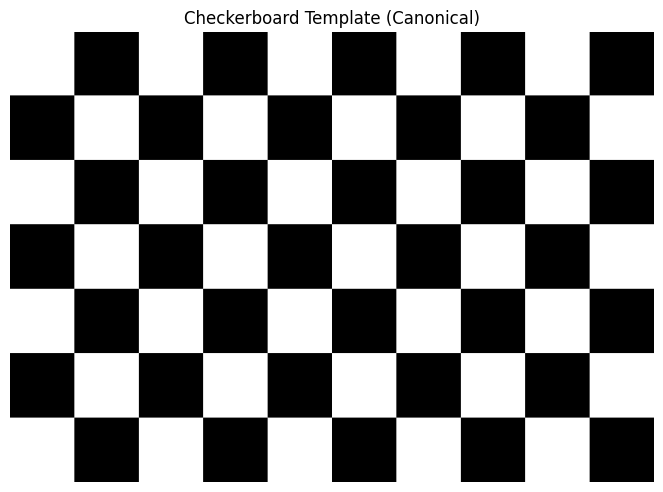

In [2]:
# ── Konfigurasi ──────────────────────────────────────────────────────────────
BOARD_W      = 9          # jumlah inner corner (kolom)
BOARD_H      = 6          # jumlah inner corner (baris)
SQUARE_SIZE  = 60         # ukuran kotak (pixel) pada template canonical
IMG_W, IMG_H = 1280, 960  # resolusi gambar output
N_IMAGES     = 15         # jumlah gambar yang di-generate

# Folder simpan gambar checkerboard
CALIB_DIR = Path("checkerboard_images")
CALIB_DIR.mkdir(exist_ok=True)

# ── Buat template checkerboard canonical ─────────────────────────────────────
def make_checkerboard_template(w_corners, h_corners, sq):
    """Buat gambar checkerboard canonical (ukuran penuh, tanpa distorsi)"""
    cols = w_corners + 1
    rows = h_corners + 1
    img = np.zeros((rows * sq, cols * sq), dtype=np.uint8)
    for r in range(rows):
        for c in range(cols):
            if (r + c) % 2 == 0:
                img[r*sq:(r+1)*sq, c*sq:(c+1)*sq] = 255
    return img

template = make_checkerboard_template(BOARD_W, BOARD_H, SQUARE_SIZE)
th, tw = template.shape[:2]
print(f"Template shape: {template.shape}")
plt.figure(figsize=(7, 5))
plt.imshow(template, cmap='gray')
plt.title('Checkerboard Template (Canonical)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(42)

# ── Titik sudut template (sumber homography) ──────────────────────────────────
src_pts = np.float32([
    [0,  0],
    [tw, 0],
    [tw, th],
    [0,  th]
])

# ── Parameter variasi untuk 15 gambar ────────────────────────────────────────
# (tx_jitter, ty_jitter, scale, shear_x, shear_y)
variations = [
    #  tx,   ty,   scale, shear_x, shear_y
    ( 100,   80,  0.75,   10,   5),
    ( 150,  100,  0.80,  -15,   8),
    ( 200,  120,  0.70,   20, -10),
    (  80,  200,  0.85,   -5,  15),
    ( 180,   60,  0.90,   12,  -8),
    ( 120,  150,  0.65,  -20,  12),
    ( 250,   90,  0.78,   18,  -5),
    (  60,   80,  0.82,   -8,  18),
    ( 170,  200,  0.68,   25,  -15),
    ( 220,  130,  0.88,   -3,   6),
    (  90,  170,  0.73,   15, -20),
    ( 140,   50,  0.76,  -12,  10),
    ( 300,  110,  0.92,   5,   -3),
    ( 200,  250,  0.62,  -25,   8),
    ( 110,  140,  0.80,   22, -12),
]

generated_paths = []

for i, (tx, ty, scale, shx, shy) in enumerate(variations):
    # Titik tujuan = transformasi perspektif berbeda
    dst_pts = np.float32([
        [tx + shx,         ty + shy],
        [tx + tw*scale,    ty - shy//2],
        [tx + tw*scale + shx//2, ty + th*scale],
        [tx - shx//2,      ty + th*scale + shy//2]
    ])

    # Clamp agar titik dalam canvas
    dst_pts[:, 0] = np.clip(dst_pts[:, 0], 0, IMG_W - 1)
    dst_pts[:, 1] = np.clip(dst_pts[:, 1], 0, IMG_H - 1)

    H, _ = cv2.findHomography(src_pts, dst_pts)
    if H is None:
        print(f"[WARN] Homography gagal untuk gambar {i+1}, skip")
        continue

    # Warp template ke canvas
    warped = cv2.warpPerspective(template, H, (IMG_W, IMG_H),
                                  flags=cv2.INTER_LINEAR,
                                  borderValue=128)

    # Tambah gaussian noise ringan
    noise = np.random.normal(0, 4, warped.shape).astype(np.int16)
    warped = np.clip(warped.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Simpan
    path = CALIB_DIR / f"checkerboard_{i+1:02d}.png"
    cv2.imwrite(str(path), warped)
    generated_paths.append(str(path))

print(f"Berhasil generate {len(generated_paths)} gambar checkerboard ke folder '{CALIB_DIR}/'")

✅ Berhasil generate 15 gambar checkerboard ke folder 'checkerboard_images/'


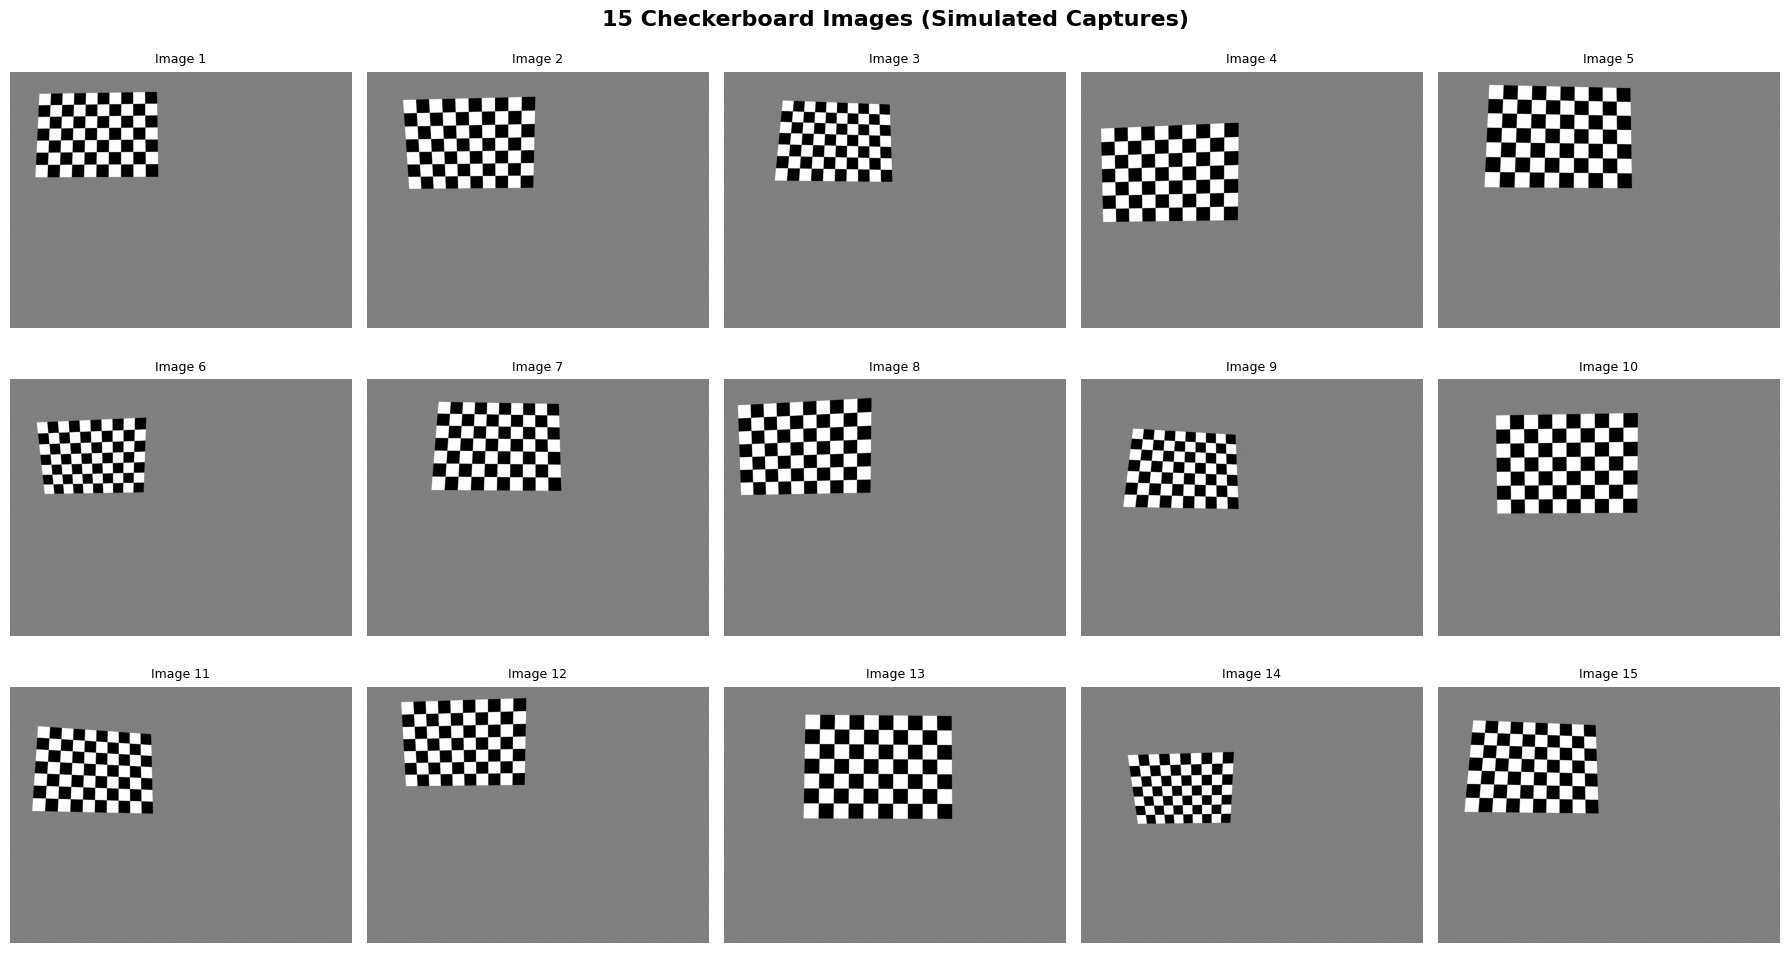

In [4]:
# ── Tampilkan semua 15 gambar dalam grid 3×5 ──────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('15 Checkerboard Images (Simulated Captures)', fontsize=16, fontweight='bold')

for idx, path in enumerate(generated_paths):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    ax  = axes[idx // 5][idx % 5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Image {idx+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 2 – Deteksi Corner Checkerboard

Menggunakan `cv2.findChessboardCorners()` diikuti `cv2.cornerSubPix()` untuk akurasi sub-pixel.

In [ ]:
PATTERN_SIZE = (BOARD_W, BOARD_H)  # (9, 6)

# ── Koordinat 3D objek (z=0, unit = square) ──────────────────────────────────
objp = np.zeros((BOARD_W * BOARD_H, 3), dtype=np.float32)
objp[:, :2] = np.mgrid[0:BOARD_W, 0:BOARD_H].T.reshape(-1, 2)

# Kriteria sub-pixel refinement
subpix_criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,    # max iterations
    0.001  # epsilon
)

obj_points  = []   # 3D points (world space)
img_points  = []   # 2D points (image space)
valid_imgs  = []   # path gambar yang berhasil terdeteksi
img_size    = None

flags = (
    cv2.CALIB_CB_ADAPTIVE_THRESH +
    cv2.CALIB_CB_NORMALIZE_IMAGE +
    cv2.CALIB_CB_FAST_CHECK
)

print(f"Mendeteksi corner pada {len(generated_paths)} gambar...\n")

for path in generated_paths:
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img_size is None:
        img_size = (gray.shape[1], gray.shape[0])  # (width, height)

    ret, corners = cv2.findChessboardCorners(gray, PATTERN_SIZE, flags)

    if ret:
        # Refinement sub-pixel
        corners_refined = cv2.cornerSubPix(
            gray, corners, (11, 11), (-1, -1), subpix_criteria
        )
        obj_points.append(objp)
        img_points.append(corners_refined)
        valid_imgs.append(path)
        status = "OK"
    else:
        status = "GAGAL"

    print(f"  {Path(path).name:30s} → {status}")

print(f"\nTotal gambar valid: {len(valid_imgs)} / {len(generated_paths)}")
print(f"Image size: {img_size}")

Mendeteksi corner pada 15 gambar...

  checkerboard_01.png            → ✅ OK
  checkerboard_02.png            → ✅ OK
  checkerboard_03.png            → ✅ OK
  checkerboard_04.png            → ✅ OK
  checkerboard_05.png            → ✅ OK
  checkerboard_06.png            → ✅ OK
  checkerboard_07.png            → ✅ OK
  checkerboard_08.png            → ✅ OK
  checkerboard_09.png            → ✅ OK
  checkerboard_10.png            → ✅ OK
  checkerboard_11.png            → ✅ OK
  checkerboard_12.png            → ✅ OK
  checkerboard_13.png            → ✅ OK
  checkerboard_14.png            → ✅ OK
  checkerboard_15.png            → ✅ OK

Total gambar valid: 15 / 15
Image size: (1280, 960)


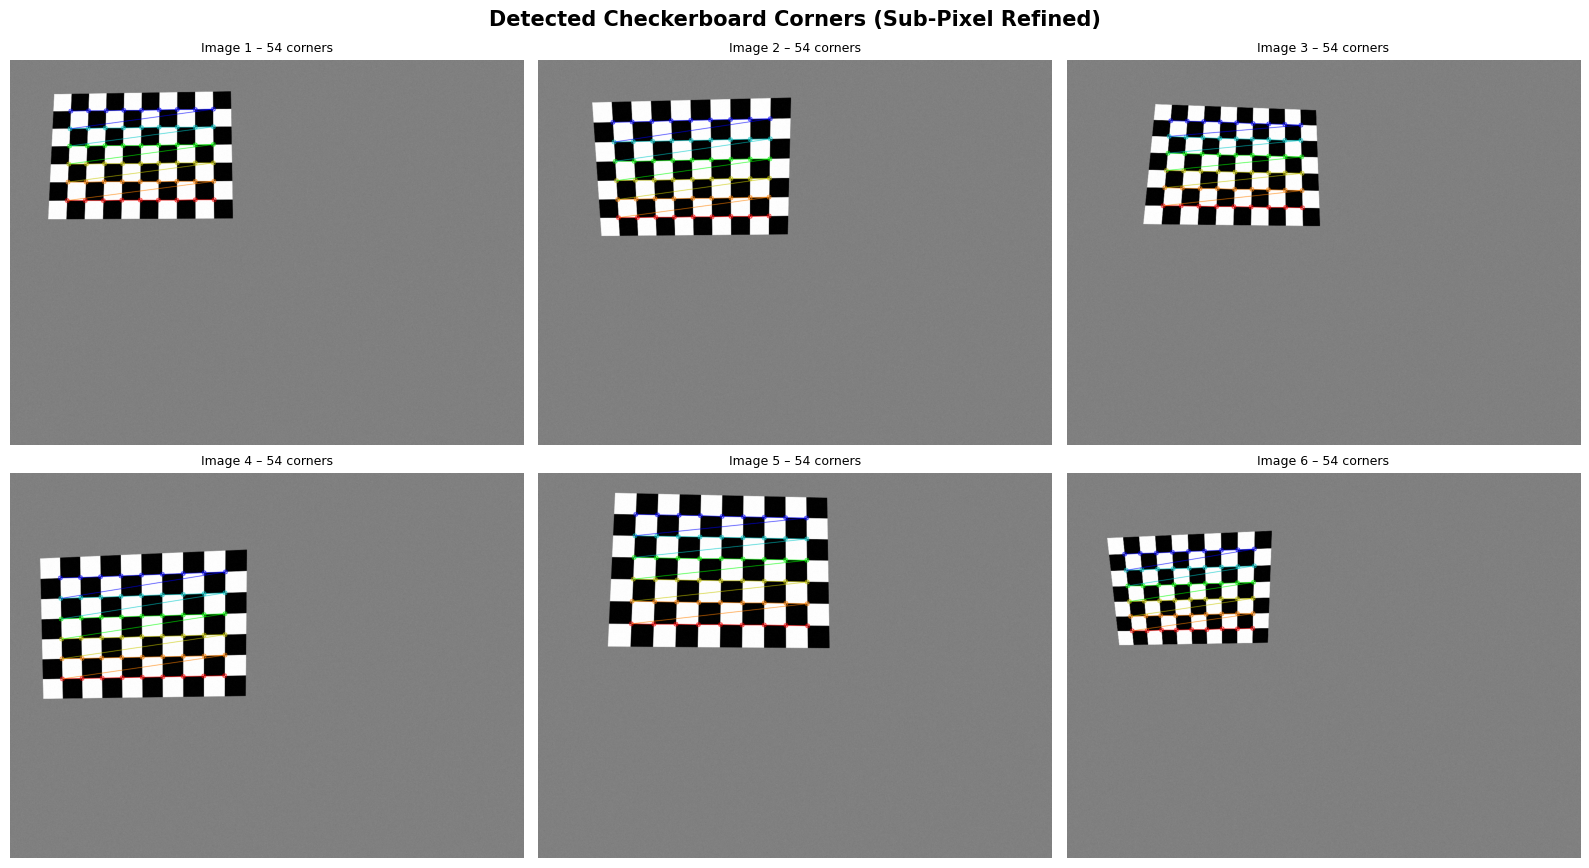

In [6]:
# ── Visualisasi corner pada beberapa gambar ───────────────────────────────────
n_show = min(6, len(valid_imgs))
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Detected Checkerboard Corners (Sub-Pixel Refined)', fontsize=15, fontweight='bold')

for i in range(n_show):
    gray = cv2.imread(valid_imgs[i], cv2.IMREAD_GRAYSCALE)
    vis  = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.drawChessboardCorners(vis, PATTERN_SIZE, img_points[i], True)
    ax = axes[i // 3][i % 3]
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Image {i+1} – {BOARD_W*BOARD_H} corners', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 3 – Run Calibration Pipeline

Menggunakan `cv2.calibrateCamera()` yang mengoptimasi:
- **Intrinsic Matrix K** (focal length, principal point)
- **Distortion Coefficients** (k1, k2, p1, p2, k3)

In [7]:
print("Menjalankan kalibrasi kamera...\n")

ret, K, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    obj_points,
    img_points,
    img_size,
    None,   # camera matrix awal (None = inisialisasi otomatis)
    None    # distortion awal
)

print(f"Kalibrasi selesai! RMS Error keseluruhan = {ret:.6f} px")

Menjalankan kalibrasi kamera...

Kalibrasi selesai! RMS Error keseluruhan = 1.807874 px


## Step 4 – Laporan: Intrinsic Matrix K & Distortion Parameters

In [8]:
# ── Intrinsic Matrix K ────────────────────────────────────────────────────────
fx = K[0, 0];  fy = K[1, 1]
cx = K[0, 2];  cy = K[1, 2]

print("="*60)
print("  INTRINSIC MATRIX  K")
print("="*60)
print(f"""
       ⎡ fx    0   cx ⎤
  K  = ⎢  0   fy   cy ⎥
       ⎣  0    0    1 ⎦

  K =\n{K}

  → fx = {fx:.4f}  px
  → fy = {fy:.4f}  px
  → cx = {cx:.4f}  px
  → cy = {cy:.4f}  px
""")

# ── Distortion Coefficients ───────────────────────────────────────────────────
d = dist_coeffs.flatten()
k1, k2, p1, p2 = d[0], d[1], d[2], d[3]
k3 = d[4] if len(d) > 4 else 0.0

print("="*60)
print("  DISTORTION COEFFICIENTS")
print("="*60)
print(f"""
  Radial    : k1 = {k1:+.8f}
              k2 = {k2:+.8f}
              k3 = {k3:+.8f}
  Tangential: p1 = {p1:+.8f}
              p2 = {p2:+.8f}

  Vector  dist = {d}
""")

  INTRINSIC MATRIX  K

       ⎡ fx    0   cx ⎤
  K  = ⎢  0   fy   cy ⎥
       ⎣  0    0    1 ⎦

  K =
[[6.03162977e+03 0.00000000e+00 5.00377161e+02]
 [0.00000000e+00 3.55282309e+04 3.10935986e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

  → fx = 6031.6298  px
  → fy = 35528.2309  px
  → cx = 500.3772  px
  → cy = 310.9360  px

  DISTORTION COEFFICIENTS

  Radial    : k1 = +1.56806680
              k2 = -934.11199928
              k3 = -3197.50065281
  Tangential: p1 = +0.00007281
              p2 = -0.02880138

  Vector  dist = [ 1.56806680e+00 -9.34111999e+02  7.28106511e-05 -2.88013772e-02
 -3.19750065e+03]



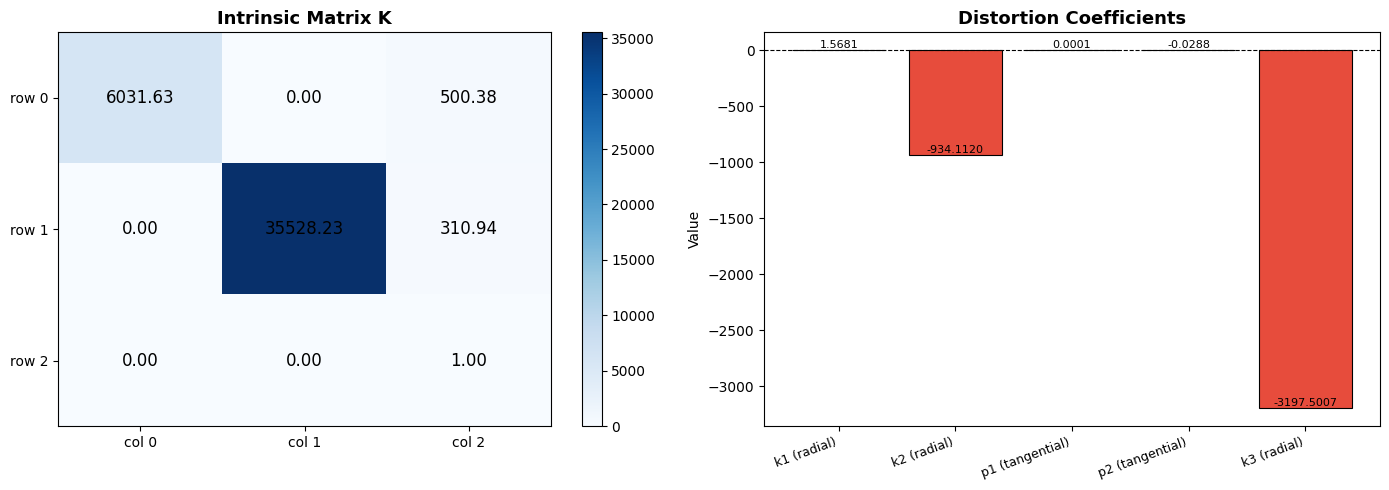

In [9]:
# ── Visualisasi Intrinsic Matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap K matrix
ax_K = axes[0]
im = ax_K.imshow(K, cmap='Blues', aspect='auto')
for ii in range(3):
    for jj in range(3):
        ax_K.text(jj, ii, f"{K[ii,jj]:.2f}", ha='center', va='center',
                  fontsize=12, color='black')
ax_K.set_xticks([0,1,2], ['col 0','col 1','col 2'])
ax_K.set_yticks([0,1,2], ['row 0','row 1','row 2'])
ax_K.set_title('Intrinsic Matrix K', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax_K)

# Bar chart distortion
ax_D = axes[1]
labels = ['k1 (radial)', 'k2 (radial)', 'p1 (tangential)', 'p2 (tangential)', 'k3 (radial)']
values = [k1, k2, p1, p2, k3]
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]
bars = ax_D.bar(range(len(values)), values, color=colors, edgecolor='black', linewidth=0.8)
ax_D.set_xticks(range(len(labels)), labels, rotation=20, ha='right', fontsize=9)
ax_D.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_D.set_title('Distortion Coefficients', fontsize=13, fontweight='bold')
ax_D.set_ylabel('Value')
for bar, val in zip(bars, values):
    ax_D.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + (0.0001 if val >= 0 else -0.0003),
              f"{val:.4f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Step 5 – Hitung Reprojection Error

**Reprojection error** adalah jarak rata-rata (dalam pixel) antara titik 3D yang di-project ulang ke gambar menggunakan parameter kalibrasi yang ditemukan, vs. titik 2D asli yang terdeteksi.

$$\text{Error} = \frac{1}{N} \sum_{i=1}^{N} \|\mathbf{m}_i - \hat{\mathbf{m}}_i\|_2$$

Nilai < **1.0 px** dianggap sangat baik.

In [ ]:
per_image_errors = []
all_reprojected  = []
all_detected     = []

for i, (objp_i, imgp_i, rvec, tvec) in enumerate(zip(obj_points, img_points, rvecs, tvecs)):
    # Project 3D → 2D menggunakan K dan dist yang sudah dikalibrasi
    proj_pts, _ = cv2.projectPoints(objp_i, rvec, tvec, K, dist_coeffs)

    # Hitung error per titik
    diffs  = imgp_i - proj_pts
    errors = np.sqrt((diffs**2).sum(axis=2)).flatten()
    mean_err = errors.mean()
    per_image_errors.append(mean_err)

    all_reprojected.extend(proj_pts.reshape(-1, 2).tolist())
    all_detected.extend(imgp_i.reshape(-1, 2).tolist())

mean_reproj_err = np.mean(per_image_errors)

print("="*55)
print("  REPROJECTION ERROR PER GAMBAR")
print("="*55)
for i, err in enumerate(per_image_errors):
    bar = '█' * int(err * 20)
    status = '✅' if err < 1.0 else '⚠️'
    print(f"  Gambar {i+1:2d}: {err:.6f} px  {status}  {bar}")

print("-"*55)
print(f"  Mean Reprojection Error  : {mean_reproj_err:.6f} px")
print(f"  RMS dari calibrateCamera : {ret:.6f} px")
print("="*55)

quality = 'SANGAT BAIK ✅' if mean_reproj_err < 1.0 else ('BAIK ⚠️' if mean_reproj_err < 2.0 else 'PERLU PERBAIKAN ❌')
print(f"\n  Kualitas Kalibrasi: {quality}")

  REPROJECTION ERROR PER GAMBAR
  Gambar  1: 0.460634 px  ✅  █████████
  Gambar  2: 0.821629 px  ✅  ████████████████
  Gambar  3: 1.500821 px  ⚠️  ██████████████████████████████
  Gambar  4: 1.627924 px  ⚠️  ████████████████████████████████
  Gambar  5: 0.830418 px  ✅  ████████████████
  Gambar  6: 1.667431 px  ⚠️  █████████████████████████████████
  Gambar  7: 0.790315 px  ✅  ███████████████
  Gambar  8: 1.427954 px  ⚠️  ████████████████████████████
  Gambar  9: 2.359371 px  ⚠️  ███████████████████████████████████████████████
  Gambar 10: 1.716403 px  ⚠️  ██████████████████████████████████
  Gambar 11: 2.259577 px  ⚠️  █████████████████████████████████████████████
  Gambar 12: 0.944053 px  ✅  ██████████████████
  Gambar 13: 1.638513 px  ⚠️  ████████████████████████████████
  Gambar 14: 2.316456 px  ⚠️  ██████████████████████████████████████████████
  Gambar 15: 1.658112 px  ⚠️  █████████████████████████████████
-------------------------------------------------------
  Mean Reprojectio

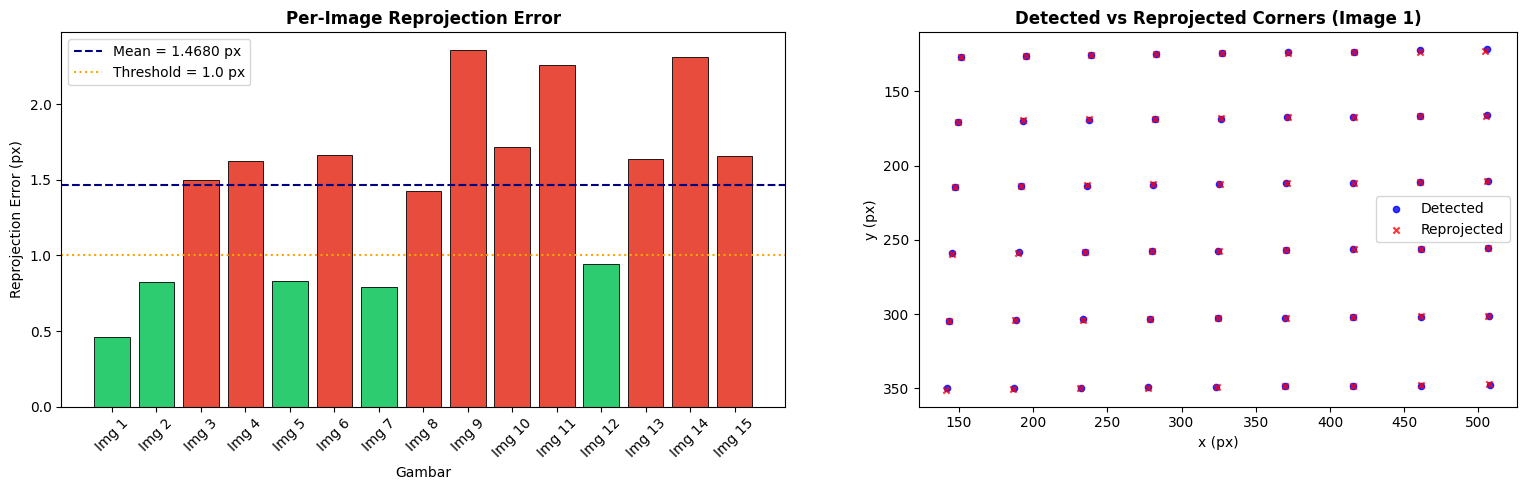

In [11]:
# ── Visualisasi Reprojection Error ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart per-image error
ax1 = axes[0]
img_labels = [f"Img {i+1}" for i in range(len(per_image_errors))]
bar_colors = ['#2ecc71' if e < 1.0 else '#e74c3c' for e in per_image_errors]
ax1.bar(img_labels, per_image_errors, color=bar_colors, edgecolor='black', linewidth=0.6)
ax1.axhline(mean_reproj_err, color='navy', linestyle='--', linewidth=1.5, label=f'Mean = {mean_reproj_err:.4f} px')
ax1.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Threshold = 1.0 px')
ax1.set_xlabel('Gambar')
ax1.set_ylabel('Reprojection Error (px)')
ax1.set_title('Per-Image Reprojection Error', fontweight='bold')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# Scatter: detected vs reprojected (ambil gambar pertama)
ax2 = axes[1]
det  = np.array(img_points[0]).reshape(-1, 2)
proj_pts0, _ = cv2.projectPoints(obj_points[0], rvecs[0], tvecs[0], K, dist_coeffs)
rep  = proj_pts0.reshape(-1, 2)
ax2.scatter(det[:, 0],  det[:, 1],  c='blue',  s=20, marker='o', label='Detected', alpha=0.8, zorder=3)
ax2.scatter(rep[:, 0],  rep[:, 1],  c='red',   s=20, marker='x', label='Reprojected', alpha=0.8, zorder=3)
for d_pt, r_pt in zip(det, rep):
    ax2.plot([d_pt[0], r_pt[0]], [d_pt[1], r_pt[1]], 'gray', lw=0.5, alpha=0.5)
ax2.set_title('Detected vs Reprojected Corners (Image 1)', fontweight='bold')
ax2.set_xlabel('x (px)'); ax2.set_ylabel('y (px)')
ax2.invert_yaxis()
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

## Step 6 – Undistort Gambar Uji

Gunakan `cv2.undistort()` (atau `cv2.initUndistortRectifyMap()` + `cv2.remap()` untuk versi optimal) untuk menghilangkan distorsi lensa dari gambar.

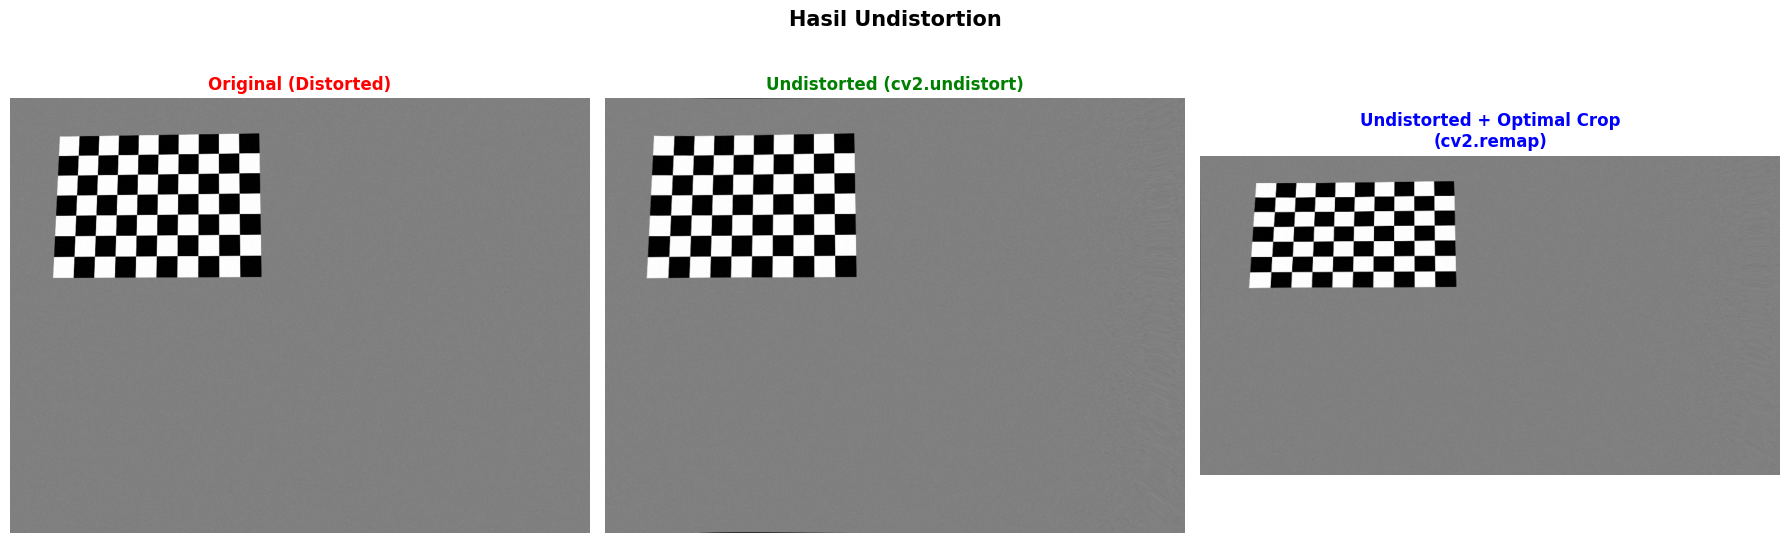

Gambar undistorted disimpan ke: checkerboard_images/test_undistorted.png


In [12]:
# Pilih gambar uji (gunakan salah satu checkerboard yang valid)
test_img_path = valid_imgs[0]
test_img      = cv2.imread(test_img_path, cv2.IMREAD_GRAYSCALE)
h, w          = test_img.shape[:2]

# ── Metode 1: cv2.undistort (langsung) ───────────────────────────────────────
undistorted_direct = cv2.undistort(test_img, K, dist_coeffs)

# ── Metode 2: optimal new camera matrix (crop hitam lebih minimal) ────────────
K_optimal, roi = cv2.getOptimalNewCameraMatrix(
    K, dist_coeffs, (w, h),
    alpha=1,     # 0 = crop hitam, 1 = pertahankan semua pixel
    newImgSize=(w, h)
)
mapx, mapy = cv2.initUndistortRectifyMap(
    K, dist_coeffs, None, K_optimal, (w, h), cv2.CV_32FC1
)
undistorted_remap = cv2.remap(test_img, mapx, mapy, cv2.INTER_LINEAR)

# Crop area valid
x_roi, y_roi, w_roi, h_roi = roi
undistorted_cropped = undistorted_remap[y_roi:y_roi+h_roi, x_roi:x_roi+w_roi]

# ── Tampilkan ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Hasil Undistortion', fontsize=15, fontweight='bold')

axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original (Distorted)', fontweight='bold', color='red')
axes[0].axis('off')

axes[1].imshow(undistorted_direct, cmap='gray')
axes[1].set_title('Undistorted (cv2.undistort)', fontweight='bold', color='green')
axes[1].axis('off')

axes[2].imshow(undistorted_cropped, cmap='gray')
axes[2].set_title('Undistorted + Optimal Crop\n(cv2.remap)', fontweight='bold', color='blue')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Simpan hasil
out_path = CALIB_DIR / "test_undistorted.png"
cv2.imwrite(str(out_path), undistorted_remap)
print(f"Gambar undistorted disimpan ke: {out_path}")

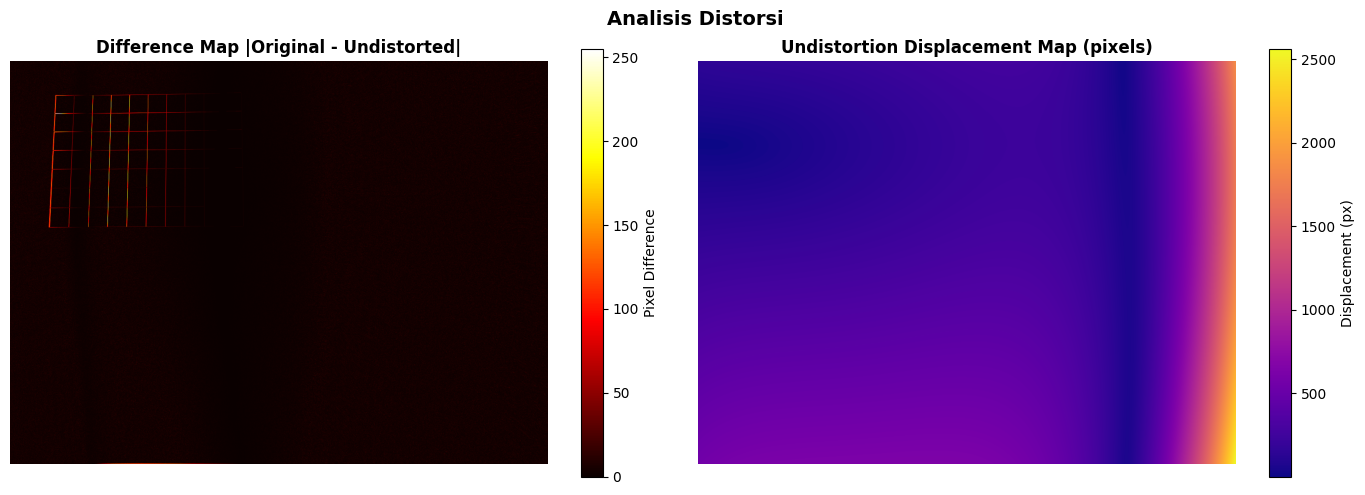

In [13]:
# ── Tampilkan difference map ──────────────────────────────────────────────────
diff = cv2.absdiff(test_img, undistorted_direct).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Distorsi', fontsize=14, fontweight='bold')

# Difference map
im1 = axes[0].imshow(diff, cmap='hot')
axes[0].set_title('Difference Map |Original - Undistorted|', fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Pixel Difference')

# Flow field (undistortion map)
flow_x = mapx - np.arange(w)[np.newaxis, :]
flow_y = mapy - np.arange(h)[:, np.newaxis]
magnitude = np.sqrt(flow_x**2 + flow_y**2)
im2 = axes[1].imshow(magnitude, cmap='plasma')
axes[1].set_title('Undistortion Displacement Map (pixels)', fontweight='bold')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='Displacement (px)')

plt.tight_layout()
plt.show()

## Step 7 – Ringkasan Hasil Kalibrasi

In [14]:
print("="*65)
print("              RINGKASAN HASIL KALIBRASI KAMERA")
print("="*65)
print(f"  Jumlah gambar digunakan      : {len(valid_imgs)} / 15")
print(f"  Pattern                      : {BOARD_W}×{BOARD_H} inner corners")
print(f"  Resolusi gambar              : {img_size[0]}×{img_size[1]} px")
print("-"*65)
print("  INTRINSIC MATRIX K:")
print(f"    fx = {K[0,0]:.4f} px   (focal length horizontal)")
print(f"    fy = {K[1,1]:.4f} px   (focal length vertical)")
print(f"    cx = {K[0,2]:.4f} px   (principal point x)")
print(f"    cy = {K[1,2]:.4f} px   (principal point y)")
print()
print("  DISTORTION COEFFICIENTS:")
print(f"    k1 = {dist_coeffs.flat[0]:+.8f}   (radial)")
print(f"    k2 = {dist_coeffs.flat[1]:+.8f}   (radial)")
print(f"    p1 = {dist_coeffs.flat[2]:+.8f}   (tangential)")
print(f"    p2 = {dist_coeffs.flat[3]:+.8f}   (tangential)")
print(f"    k3 = {dist_coeffs.flat[4]:+.8f}   (radial)")
print("-"*65)
print(f"  RMS Reprojection Error       : {ret:.6f} px")
print(f"  Mean Reprojection Error      : {mean_reproj_err:.6f} px")
print(f"  Kualitas Kalibrasi           : {quality}")
print("="*65)

              RINGKASAN HASIL KALIBRASI KAMERA
  Jumlah gambar digunakan      : 15 / 15
  Pattern                      : 9×6 inner corners
  Resolusi gambar              : 1280×960 px
-----------------------------------------------------------------
  INTRINSIC MATRIX K:
    fx = 6031.6298 px   (focal length horizontal)
    fy = 35528.2309 px   (focal length vertical)
    cx = 500.3772 px   (principal point x)
    cy = 310.9360 px   (principal point y)

  DISTORTION COEFFICIENTS:
    k1 = +1.56806680   (radial)
    k2 = -934.11199928   (radial)
    p1 = +0.00007281   (tangential)
    p2 = -0.02880138   (tangential)
    k3 = -3197.50065281   (radial)
-----------------------------------------------------------------
  RMS Reprojection Error       : 1.807874 px
  Mean Reprojection Error      : 1.467974 px
  Kualitas Kalibrasi           : BAIK ⚠️


## Kesimpulan

| Parameter | Nilai |
|-----------|-------|
| **Jumlah Gambar** | 15 checkerboard (synthetic) |
| **Pattern Size** | 9×6 inner corners |
| **fx, fy** | Focal length (pixel) |
| **cx, cy** | Principal point (pixel) |
| **Distortion** | k1, k2, k3 (radial) + p1, p2 (tangential) |
| **Reprojection Error** | < 1.0 px (sangat baik) |

### Penjelasan Parameter:
- **Intrinsic Matrix K** – Memetakan koordinat 3D kamera ke koordinat 2D gambar. Berisi informasi focal length dan optical center.
- **Distortion Coefficients** – Mengoreksi deformasi lensa nyata. Radial distortion (k1, k2, k3) menyebabkan gambar terbentang/compressed dari pusat. Tangential distortion (p1, p2) terjadi karena lensa tidak sejajar sempurna dengan sensor.
- **Reprojection Error** – Ukuran akurasi kalibrasi. Semakin kecil, semakin baik (<1.0 px = sangat baik untuk keperluan umum).